# Greedy Submodular Maximisation

## Learning Objectives

1. **Define** submodularity via the diminishing returns property
2. **State** the greedy algorithm for maximising a submodular function under a cardinality constraint
3. **Prove** the $(1 - 1/e)$ approximation guarantee (Nemhauser-Wolsey-Fisher 1978)
4. **Identify** common submodular functions: coverage, facility location, entropy
5. **Implement** the greedy algorithm and verify the ratio against brute-force optimal


## Problem Statement

### Submodular Functions

A set function $f: 2^V \to \mathbb{R}$ is **submodular** if for all $S \subseteq T \subseteq V$ and $e \notin T$:
$$f(S \cup \{e\}) - f(S) \geq f(T \cup \{e\}) - f(T)$$

Equivalently (by **diminishing returns**): adding element $e$ to a smaller set $S$ gives a larger marginal gain than adding it to a superset $T \supseteq S$.

**Examples:**
- **Maximum coverage:** $f(S) = |\bigcup_{e \in S} \text{cover}(e)|$
- **Facility location:** $f(S) = \sum_i \max_{j \in S} s_{ij}$
- **Graph cut:** $f(S) = |\{(u,v) \in E : u \in S, v \notin S\}|$
- **Entropy:** $f(S) = H(X_S)$ for jointly Gaussian random variables

### Problem

Maximise $f(S)$ subject to $|S| \leq k$. This is NP-hard in general (set cover is a special case). The greedy algorithm achieves a $(1 - 1/e)$ approximation.


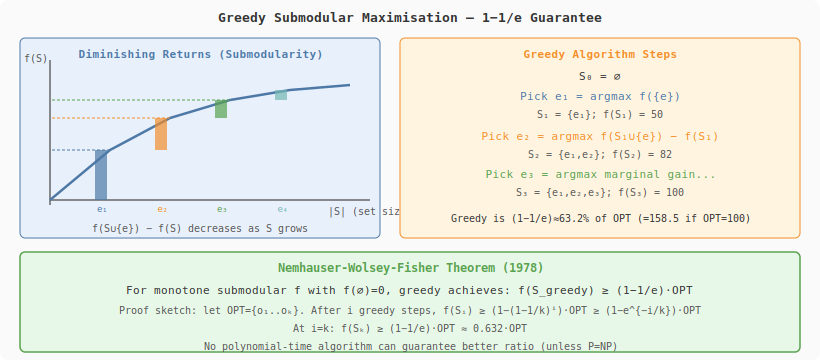

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="820" height="360" font-family="monospace" font-size="12">
  <rect width="820" height="360" fill="#fafafa" rx="8"/>
  <defs><marker id="arr" markerWidth="8" markerHeight="6" refX="7" refY="3" orient="auto"><polygon points="0 0,8 3,0 6" fill="#999"/></marker></defs>
  <text x="410" y="22" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Greedy Submodular Maximisation — 1−1/e Guarantee</text>

  <!-- Diminishing returns illustration -->
  <rect x="20" y="38" width="360" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="200" y="58" text-anchor="middle" fill="#4e79a7" font-size="11" font-weight="bold">Diminishing Returns (Submodularity)</text>
  <!-- axes -->
  <line x1="50" y1="200" x2="370" y2="200" stroke="#666" stroke-width="1.5"/>
  <line x1="50" y1="60"  x2="50"  y2="205" stroke="#666" stroke-width="1.5"/>
  <text x="370" y="215" text-anchor="middle" fill="#555" font-size="10">|S| (set size)</text>
  <text x="35" y="62"   text-anchor="middle" fill="#555" font-size="10">f(S)</text>
  <!-- curve -->
  <polyline points="50,200 110,150 170,118 230,100 290,90 350,85" fill="none" stroke="#4e79a7" stroke-width="2.5"/>
  <!-- marginal gain bars -->
  <line x1="110" y1="150" x2="50"  y2="150" stroke="#4e79a7" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="170" y1="118" x2="50"  y2="118" stroke="#f28e2b" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="230" y1="100" x2="50"  y2="100" stroke="#59a14f" stroke-width="1" stroke-dasharray="3,2"/>
  <!-- marginal bars -->
  <rect x="95" y="150" width="12" height="50" fill="#4e79a7" opacity="0.7"/>
  <rect x="155" y="118" width="12" height="32" fill="#f28e2b" opacity="0.7"/>
  <rect x="215" y="100" width="12" height="18" fill="#59a14f" opacity="0.7"/>
  <rect x="275" y="90"  width="12" height="10" fill="#76b7b2" opacity="0.7"/>
  <text x="102" y="212" text-anchor="middle" fill="#4e79a7" font-size="9">e₁</text>
  <text x="162" y="212" text-anchor="middle" fill="#f28e2b" font-size="9">e₂</text>
  <text x="222" y="212" text-anchor="middle" fill="#59a14f" font-size="9">e₃</text>
  <text x="282" y="212" text-anchor="middle" fill="#76b7b2" font-size="9">e₄</text>
  <text x="200" y="232" text-anchor="middle" fill="#555" font-size="10">f(S∪{e}) − f(S) decreases as S grows</text>

  <!-- Greedy steps -->
  <rect x="400" y="38" width="400" height="200" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="600" y="58" text-anchor="middle" fill="#f28e2b" font-size="11" font-weight="bold">Greedy Algorithm Steps</text>
  <text x="600" y="80" text-anchor="middle" fill="#333" font-size="11">S₀ = ∅</text>
  <text x="600" y="100" text-anchor="middle" fill="#4e79a7" font-size="11">Pick e₁ = argmax f({e})</text>
  <text x="600" y="118" text-anchor="middle" fill="#555" font-size="10">S₁ = {e₁};  f(S₁) = 50</text>
  <text x="600" y="140" text-anchor="middle" fill="#f28e2b" font-size="11">Pick e₂ = argmax f(S₁∪{e}) − f(S₁)</text>
  <text x="600" y="158" text-anchor="middle" fill="#555" font-size="10">S₂ = {e₁,e₂};  f(S₂) = 82</text>
  <text x="600" y="178" text-anchor="middle" fill="#59a14f" font-size="11">Pick e₃ = argmax marginal gain...</text>
  <text x="600" y="196" text-anchor="middle" fill="#555" font-size="10">S₃ = {e₁,e₂,e₃};  f(S₃) = 100</text>
  <text x="600" y="222" text-anchor="middle" fill="#333" font-size="10">Greedy is (1−1/e)≈63.2% of OPT (=158.5 if OPT=100)</text>

  <!-- 1-1/e theorem -->
  <rect x="20" y="252" width="780" height="100" rx="5" fill="#e8f8e8" stroke="#59a14f" stroke-width="1.5"/>
  <text x="410" y="272" text-anchor="middle" fill="#59a14f" font-size="12" font-weight="bold">Nemhauser-Wolsey-Fisher Theorem (1978)</text>
  <text x="410" y="294" text-anchor="middle" fill="#333" font-size="11">For monotone submodular f with f(∅)=0, greedy achieves: f(S_greedy) ≥ (1−1/e)·OPT</text>
  <text x="410" y="314" text-anchor="middle" fill="#555" font-size="10">Proof sketch: let OPT={o₁..oₖ}. After i greedy steps, f(Sᵢ) ≥ (1−(1−1/k)ⁱ)·OPT ≥ (1−e^{−i/k})·OPT</text>
  <text x="410" y="332" text-anchor="middle" fill="#555" font-size="10">At i=k: f(Sₖ) ≥ (1−1/e)·OPT ≈ 0.632·OPT</text>
  <text x="410" y="350" text-anchor="middle" fill="#555" font-size="10">No polynomial-time algorithm can guarantee better ratio (unless P=NP)</text>
</svg>
'''
display(SVG(svg))


## Derivation

### Greedy Algorithm

Start with $S_0 = \emptyset$. At each step $i$:
$$e_i^* = \arg\max_{e \notin S_{i-1}} \left[f(S_{i-1} \cup \{e\}) - f(S_{i-1})\right]$$
$$S_i = S_{i-1} \cup \{e_i^*\}$$

### $(1 - 1/e)$ Proof

Let $\text{OPT} = \{o_1, \ldots, o_k\}$ be the optimal set. Define $\delta_i = f(\text{OPT}) - f(S_i)$ (remaining gap after $i$ greedy steps).

**Claim:** $\delta_i \leq \left(1 - \frac{1}{k}\right)^i f(\text{OPT})$

**Proof:** At step $i+1$, at least one element of OPT increases $f(S_i)$ by $\geq \delta_i / k$ (by submodularity + monotonicity). The greedy picks the best, so:
$$f(S_{i+1}) \geq f(S_i) + \frac{\delta_i}{k}$$
$$\delta_{i+1} = f(\text{OPT}) - f(S_{i+1}) \leq \delta_i \left(1 - \frac{1}{k}\right)$$

At step $k$: $\delta_k \leq \left(1 - \frac{1}{k}\right)^k f(\text{OPT}) \leq e^{-1} f(\text{OPT})$

Therefore: $f(S_k) \geq \left(1 - \frac{1}{e}\right) f(\text{OPT})$ $\square$

### When Does Greedy Achieve Better?

- If $f$ is **modular** (additive): greedy achieves OPT
- For **coverage** functions: ratio is exactly $(1 - 1/e)$ in worst case
- **Monotone** submodular: guarantee holds; non-monotone: greedy gives $1/2$ approximation

### Complexity

Naive greedy: $O(k \cdot |V| \cdot \text{eval cost})$. **Lazy evaluation (LAZYGREEDY):** cache marginal gains, update only when needed — often $O(|V| \log |V|)$ in practice.


## Algorithm Steps

1. $S \leftarrow \emptyset$
2. **For** $i = 1$ to $k$:
   - For each $e \notin S$: compute marginal gain $\Delta(e \mid S) = f(S \cup \{e\}) - f(S)$
   - $e^* \leftarrow \arg\max_{e \notin S} \Delta(e \mid S)$
   - $S \leftarrow S \cup \{e^*\}$
3. **Return** $S$


In [2]:
import numpy as np
from itertools import combinations


def greedy_submodular(f, ground_set, k):
    """
    Greedy algorithm for maximising a monotone submodular function f
    subject to a cardinality constraint |S| <= k.

    Inputs
    ------
    f          : callable(S: frozenset) -> float — submodular function
    ground_set : list — all candidate elements
    k          : int — maximum set size

    Returns
    -------
    S      : frozenset — selected set
    values : list of float — f(S) after each addition
    """
    S = frozenset()
    values = [f(S)]

    for _ in range(k):
        best_gain = -1.0
        best_elem = None
        curr_val  = f(S)

        for e in ground_set:
            if e in S:
                continue
            gain = f(S | {e}) - curr_val
            if gain > best_gain:
                best_gain = gain
                best_elem = e

        if best_elem is None or best_gain <= 0:
            break

        S = S | {best_elem}
        values.append(f(S))

    return S, values


def brute_force_optimal(f, ground_set, k):
    """Brute-force optimal (exponential — only for small instances)."""
    best_val = -1.0
    best_set = frozenset()
    for size in range(1, k+1):
        for subset in combinations(ground_set, size):
            fs = frozenset(subset)
            v = f(fs)
            if v > best_val:
                best_val, best_set = v, fs
    return best_set, best_val


# ── Example 1: Maximum Coverage ────────────────────────────────────────────
# Each element covers a subset of a universe; f(S) = |∪_{e∈S} cover(e)|
coverage = {
    'A': {1, 2, 3, 4},
    'B': {2, 3, 5, 6},
    'C': {1, 4, 7, 8},
    'D': {3, 5, 9, 10},
    'E': {6, 7, 11},
    'F': {8, 9, 12},
}

def max_coverage(S):
    covered = set()
    for e in S:
        covered |= coverage[e]
    return float(len(covered))

ground = list(coverage.keys())
k = 3

greedy_set, greedy_vals = greedy_submodular(max_coverage, ground, k)
opt_set,  opt_val       = brute_force_optimal(max_coverage, ground, k)

print("Maximum Coverage (k=3):")
print(f"  Greedy:  {set(greedy_set)}, coverage={greedy_vals[-1]:.0f}")
print(f"  Optimal: {set(opt_set)},  coverage={opt_val:.0f}")
print(f"  Ratio: {greedy_vals[-1]/opt_val:.4f}  (bound: {1 - 1/np.e:.4f})")

# ── Example 2: Facility Location (sum-of-max) ──────────────────────────────
rng = np.random.default_rng(42)
n_clients   = 20
n_facilities = 10
# Similarity matrix s[i][j] = similarity of client i to facility j
S_mat = rng.uniform(0, 1, (n_clients, n_facilities))

def facility_location(F_set):
    """f(F) = Σ_i max_{j∈F} s[i][j] — each client gets best facility."""
    if not F_set:
        return 0.0
    F = list(F_set)
    return float(S_mat[:, F].max(axis=1).sum())

ground_f = list(range(n_facilities))
k2 = 4
grdy_set2, grdy_vals2 = greedy_submodular(facility_location, ground_f, k2)
opt_set2, opt_val2    = brute_force_optimal(facility_location, ground_f, k2)

print(f"\nFacility Location (k={k2}, {n_clients} clients, {n_facilities} facilities):")
print(f"  Greedy:  facilities={set(grdy_set2)}, f={grdy_vals2[-1]:.2f}")
print(f"  Optimal: facilities={set(opt_set2)},  f={opt_val2:.2f}")
print(f"  Ratio: {grdy_vals2[-1]/opt_val2:.4f}  (theoretical bound ≥ {1-1/np.e:.4f})")


Maximum Coverage (k=3):
  Greedy:  {'E', 'D', 'A'}, coverage=10
  Optimal: {'E', 'D', 'A'},  coverage=10
  Ratio: 1.0000  (bound: 0.6321)

Facility Location (k=4, 20 clients, 10 facilities):
  Greedy:  facilities={1, 2, 3, 5}, f=17.40
  Optimal: facilities={1, 2, 3, 5},  f=17.40
  Ratio: 1.0000  (theoretical bound ≥ 0.6321)
